In [ ]:
! pip install rasterio rasterstats -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 65.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 14.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import sys
import glob
from pathlib import Path

import requests
import json
import xml.etree.ElementTree as ET
import certifi

import pandas as pd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.windows import Window
import matplotlib.pyplot as plt
import matplotlib.image
import folium
import cv2
import geopandas as gpd
from rasterstats import zonal_stats

from pyproj import Proj, transform

Following the installation and import of libraries, we proceed to explore the data catalog using specific parameters. These include the satellite name, product level (S2MSI2A for surface reflectance), AOI (either point or polygon), and the start and end dates.

In [ ]:
url_dataspace = "https://catalogue.dataspace.copernicus.eu/odata/v1"

# Filtering
satellite = "SENTINEL-2"
level = "S2MSI2A"
cloud_cover_max = 0.2

aoi_point ="POINT (24.095764 56.950217)" #The geographic reference for our area of interest

start_date = "2023-09-21"
end_date = "2023-09-22"
start_date_full =start_date+"T00:00:00.000Z"
end_date_full = end_date +"T00:00:00.000Z"

With these parameters, we can submit a query to retrieve a list of available images. Ensure that the dataframe has been filtered to include only products with a status of “online”:

In [ ]:
query = f"{url_dataspace}/Products?$filter=Collection/Name eq '{satellite}' and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq '{level}') and OData.CSC.Intersects(area=geography'SRID=4326;{aoi_point}') and ContentDate/Start gt {start_date_full} and ContentDate/Start lt {end_date_full}"
response = requests.get(query).json()
result = pd.DataFrame.from_dict(response["value"])

# Filter records where 'online' column is True
result = result[result['Online'] == True]

# print first 10 results
result.head(10)

,@odata.mediaContentType,Id,Name,ContentType,ContentLength,OriginDate,PublicationDate,ModificationDate,Online,EvictionDate,S3Path,Checksum,ContentDate,Footprint,GeoFootprint
0,application/octet-stream,1de62670-72bc-42dc-9e42-1c0c7c5d8ba9,S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_2...,application/octet-stream,1103539805,2023-09-21T17:21:00.553Z,2023-09-21T17:27:50.618Z,2023-09-21T17:28:11.021Z,True,,/eodata/Sentinel-2/MSI/L2A/2023/09/21/S2A_MSIL...,"[{'Value': '5604fae0921e3564bfd27e42b6953dd4',...","{'Start': '2023-09-21T09:40:31.024Z', 'End': '...",geography'SRID=4326;POLYGON ((23.6438298900325...,"{'type': 'Polygon', 'coordinates': [[[23.64382..."
1,application/octet-stream,25708026-43f7-45e0-9a16-37fda7a2df1f,S2A_MSIL2A_20230921T094031_N0509_R036_T34VFJ_2...,application/octet-stream,983725792,2023-09-21T17:16:30.386Z,2023-09-21T17:27:30.796Z,2023-09-21T17:27:45.705Z,True,,/eodata/Sentinel-2/MSI/L2A/2023/09/21/S2A_MSIL...,"[{'Value': 'ace53df9e562f9100afdc89581a48761',...","{'Start': '2023-09-21T09:40:31.024Z', 'End': '...",geography'SRID=4326;POLYGON ((22.6793206704832...,"{'type': 'Polygon', 'coordinates': [[[22.67932..."


After obtaining a list of available images, the next steps involve generating a token using our credentials, establishing a session, and downloading the metadata. For surface reflectance products, we’ll download MTD_MSIL2A.xml.

In [ ]:
#Login info
username = 'agrisscan2@inbox.lv'
password = 'QPaR793+/mases'


auth_server_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
data = {
    "client_id": "cdse-public",
    "grant_type": "password",
    "username": username,
    "password": password,
}

response = requests.post(auth_server_url, data=data, verify=True, allow_redirects=False)
access_token = json.loads(response.text)["access_token"]
# Establish session
session = requests.Session()
session.headers["Authorization"] = f"Bearer {access_token}"

product_row_id = 0   # 0 for the first product in the list
product_id = result.iloc[product_row_id, 1]
print(product_id)
product_name = result.iloc[product_row_id, 2]
print(product_name)

url_MTD = f"{url_dataspace}/Products({product_id})/Nodes({product_name})/Nodes(MTD_MSIL2A.xml)/$value"
response = session.get(url_MTD, allow_redirects=False)
while response.status_code in (301, 302, 303, 307):
    url_MTD_location = response.headers["Location"]
    response = session.get(url_MTD_location, allow_redirects=False)

file = session.get(url_MTD_location, verify=False, allow_redirects=True)

# Save the product in home directory
outfile = Path("/content/MTD_MSIL2A.xml")
outfile.write_bytes(file.content)

1de62670-72bc-42dc-9e42-1c0c7c5d8ba9
S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_20230921T151458.SAFE


54859

After executing these lines, you should find the metadata file in your folder. In the following lines, we will read the metadata to identify the file path of each Sentinel-2 band.

In [ ]:
# Pass the path of the xml document
tree = ET.parse(str(outfile))
# get the parent tag
root = tree.getroot()

# Get the location of individual bands in Sentinel-2 granule
band_path = []
band_path.append(f"{product_name}/{root[0][0][12][0][0][0].text}.jp2".split("/"))
band_path.append(f"{product_name}/{root[0][0][12][0][0][1].text}.jp2".split("/"))
band_path.append(f"{product_name}/{root[0][0][12][0][0][2].text}.jp2".split("/"))
band_path.append(f"{product_name}/{root[0][0][12][0][0][3].text}.jp2".split("/"))

In this example, we will download the red, green, blue, and NIR bands. You can modify the last indices to read other bands. To identify the band locations, you can use the “band_path” command

In [ ]:
band_path

[['S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_20230921T151458.SAFE',
  'GRANULE',
  'L2A_T35VLD_A043076_20230921T094329',
  'IMG_DATA',
  'R10m',
  'T35VLD_20230921T094031_B02_10m.jp2'],
 ['S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_20230921T151458.SAFE',
  'GRANULE',
  'L2A_T35VLD_A043076_20230921T094329',
  'IMG_DATA',
  'R10m',
  'T35VLD_20230921T094031_B03_10m.jp2'],
 ['S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_20230921T151458.SAFE',
  'GRANULE',
  'L2A_T35VLD_A043076_20230921T094329',
  'IMG_DATA',
  'R10m',
  'T35VLD_20230921T094031_B04_10m.jp2'],
 ['S2A_MSIL2A_20230921T094031_N0509_R036_T35VLD_20230921T151458.SAFE',
  'GRANULE',
  'L2A_T35VLD_A043076_20230921T094329',
  'IMG_DATA',
  'R10m',
  'T35VLD_20230921T094031_B08_10m.jp2']]

Once all the bands are located, you can download them one by one using the following lines:

In [ ]:
# Build the url
for band_node in band_path:
    url_full = f"{url_dataspace}/Products({product_id})/Nodes({product_name})/Nodes({band_node[1]})/Nodes({band_node[2]})/Nodes({band_node[3]})/Nodes({band_node[4]})/Nodes({band_node[5]})/$value"
    #print(url_full)
    response = session.get(url_full, allow_redirects=False)
    while response.status_code in (301, 302, 303, 307):
        url_full_location = response.headers["Location"]
        response = session.get(url_full_location, allow_redirects=False)
    file = session.get(url_full_location, verify=False, allow_redirects=True)
    # Save the product
    outfile =Path("/content/"+band_node[5])
    outfile.write_bytes(file.content)
    print("Saved:", band_node[5])

Saved: T35VLD_20230921T094031_B02_10m.jp2
Saved: T35VLD_20230921T094031_B03_10m.jp2
Saved: T35VLD_20230921T094031_B04_10m.jp2
Saved: T35VLD_20230921T094031_B08_10m.jp2


Until now, we have only downloaded the raw red, blue, green, and NIR bands of the Sentinel-2 satellites for our AOI point. In this section, we will read our AOI polygon, read each band in the “jp2” format, convert the AOI projection to match the “jp2” file’s projection, clip each band for our AOI polygon, convert each band to Geotiff, stack the GeoTIFF files, export the stacked file, and visualize it in RGB:

In [ ]:
# Read the shapefile
aoi_geom = gpd.read_file('Riga_bounds.shp')

# Get a list of input files
input_files = glob.glob('T35VLD_*_B0[2-8]_10m.jp2')
input_files = sorted(input_files, reverse=True)
print(input_files)

# Read the CRS from one of the input files
with rasterio.open(input_files[0]) as src:
    input_crs = src.crs

# Convert the AOI polygon to the input CRS
aoi_geom = aoi_geom.to_crs(input_crs)

band_mapping = {
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B08": "infra-red",
}

# Clip and save each band individually
output_files = []
for i, input_file in enumerate(input_files):
    band_name = input_file.split('_')[-2].split('.')[0]
    with rasterio.open(input_file) as src:
        # Clip the image
        out_image, out_transform = mask(src, aoi_geom.geometry, crop=True)

        # Update the metadata
        out_meta = src.meta.copy()
        out_meta.update({"driver": "GTiff",
                         "height": out_image.shape[1],
                         "width": out_image.shape[2],
                         "transform": out_transform})

        # Save the clipped image as a GeoTIFF
        output_file = f"clipped_{band_name}.tif"
        with rasterio.open(output_file, "w", **out_meta) as dest:
            dest.write(out_image)

        output_files.append(output_file)

# Stack the RGB bands (B02, B03, B04)
rgb_files = [f"clipped_{band_name}.tif" for band_name in ["B02", "B03", "B04"]]
stacked_meta = out_meta.copy()
stacked_meta.update({"count": len(rgb_files)})

stacked_array = None
for rgb_file in rgb_files:
    with rasterio.open(rgb_file) as src:
        band_array = src.read()
        if stacked_array is None:
            stacked_array = band_array
        else:
            stacked_array = np.concatenate((stacked_array, band_array), axis=0)

# Save the stacked RGB array as a GeoTIFF
with rasterio.open("stacked_SR.tif", "w", **stacked_meta) as dest:
    dest.write(stacked_array)
    dest.descriptions = ("blue", "green", "red")

# Plot the stacked RGB image
with rasterio.open("stacked_SR.tif") as src:
    show(src)

ERROR:fiona._env:Riga_bounds.shp: No such file or directory


DriverError: ignored

To understand the value distribution in our clipped image we can plot the histogram

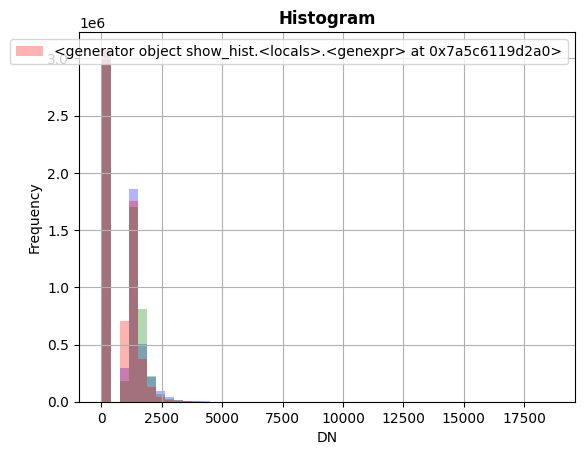

In [ ]:
# Image histogramm visualisation
with rasterio.open("stacked_SR.tif") as src:
    rasterio.plot.show_hist(src, bins=50, histtype='stepfilled', lw=0.0, stacked=False, alpha=0.3)

In order to change the visual appearance of the image we can stretch the image  

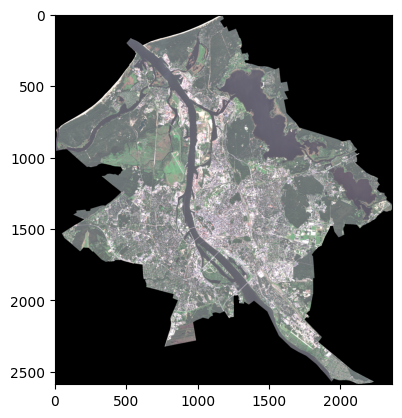

In [ ]:
# Open the file
raster = rasterio.open('/content/stacked_SR.tif')

# Stretch each band by standard deviation
def stretch_by_std(band):
    band_mean, band_std = band.mean(), band.std()
    lower_bound = band_mean - 0.5 * band_std
    upper_bound = band_mean + 2 * band_std
    return np.clip((band - lower_bound) / (upper_bound - lower_bound), 0, 1)

# Read bands
blue = raster.read(3)
red = raster.read(2)
green = raster.read(1)

# Stretch each band by standard deviation
blue_stretched = stretch_by_std(blue)
red_stretched = stretch_by_std(red)
green_stretched = stretch_by_std(green)

# Stack stretched bands
nrg_stretched = np.dstack((blue_stretched, red_stretched, green_stretched))

# View the color composite
plt.imshow(nrg_stretched)
plt.show()

For further interactive visualisation the geographical bounding box is needed. We will calculate the bounding box from the shape file that we used for clipping

In [ ]:
# Read the shapefile
shapefile_path = '/content/Riga_bounds.shp'
gdf = gpd.read_file(shapefile_path)

# Get the bounding box from the GeoDataFrame
bbox = gdf.total_bounds
print(bbox)

#*****************************************************
#Koda sadaļa, ja vektorfaila crs nesakrīt ar rastra crs

# Define the coordinate systems
shapefile_crs = gdf.crs
wgs84_crs = Proj(init='epsg:4326')  # WGS84 CRS

# Transform bounding box to WGS84
lon_min, lat_min = transform(shapefile_crs, wgs84_crs, bbox[0], bbox[1])
lon_max, lat_max = transform(shapefile_crs, wgs84_crs, bbox[2], bbox[3])

#*****************************************************

# Create bounding box in degrees
degree_bbox = [[lon_min, lat_min], [lon_max, lat_max]]

print(degree_bbox)

[23.9325504 56.8573461 24.3245041 57.0861068]
[[56.8573461, 23.9325504], [57.0861068, 24.3245041]]


/usr/local/lib/python3.10/dist-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
<ipython-input-13-23180e85127d>:17: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon_min, lat_min = transform(shapefile_crs, wgs84_crs, bbox[0], bbox[1])
<ipython-input-13-23180e85127d>:18: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon_max, lat_max = transform(shapefile_crs, wgs84_crs, bbox[2], bbox[3])


By using folium package we can create an interactive map with clipped Sentinel-2 image. Folium does not support Geotiff format so we need to extract the visual information in to .png file and use the geographical coordinates obtained previously to place the image on the map


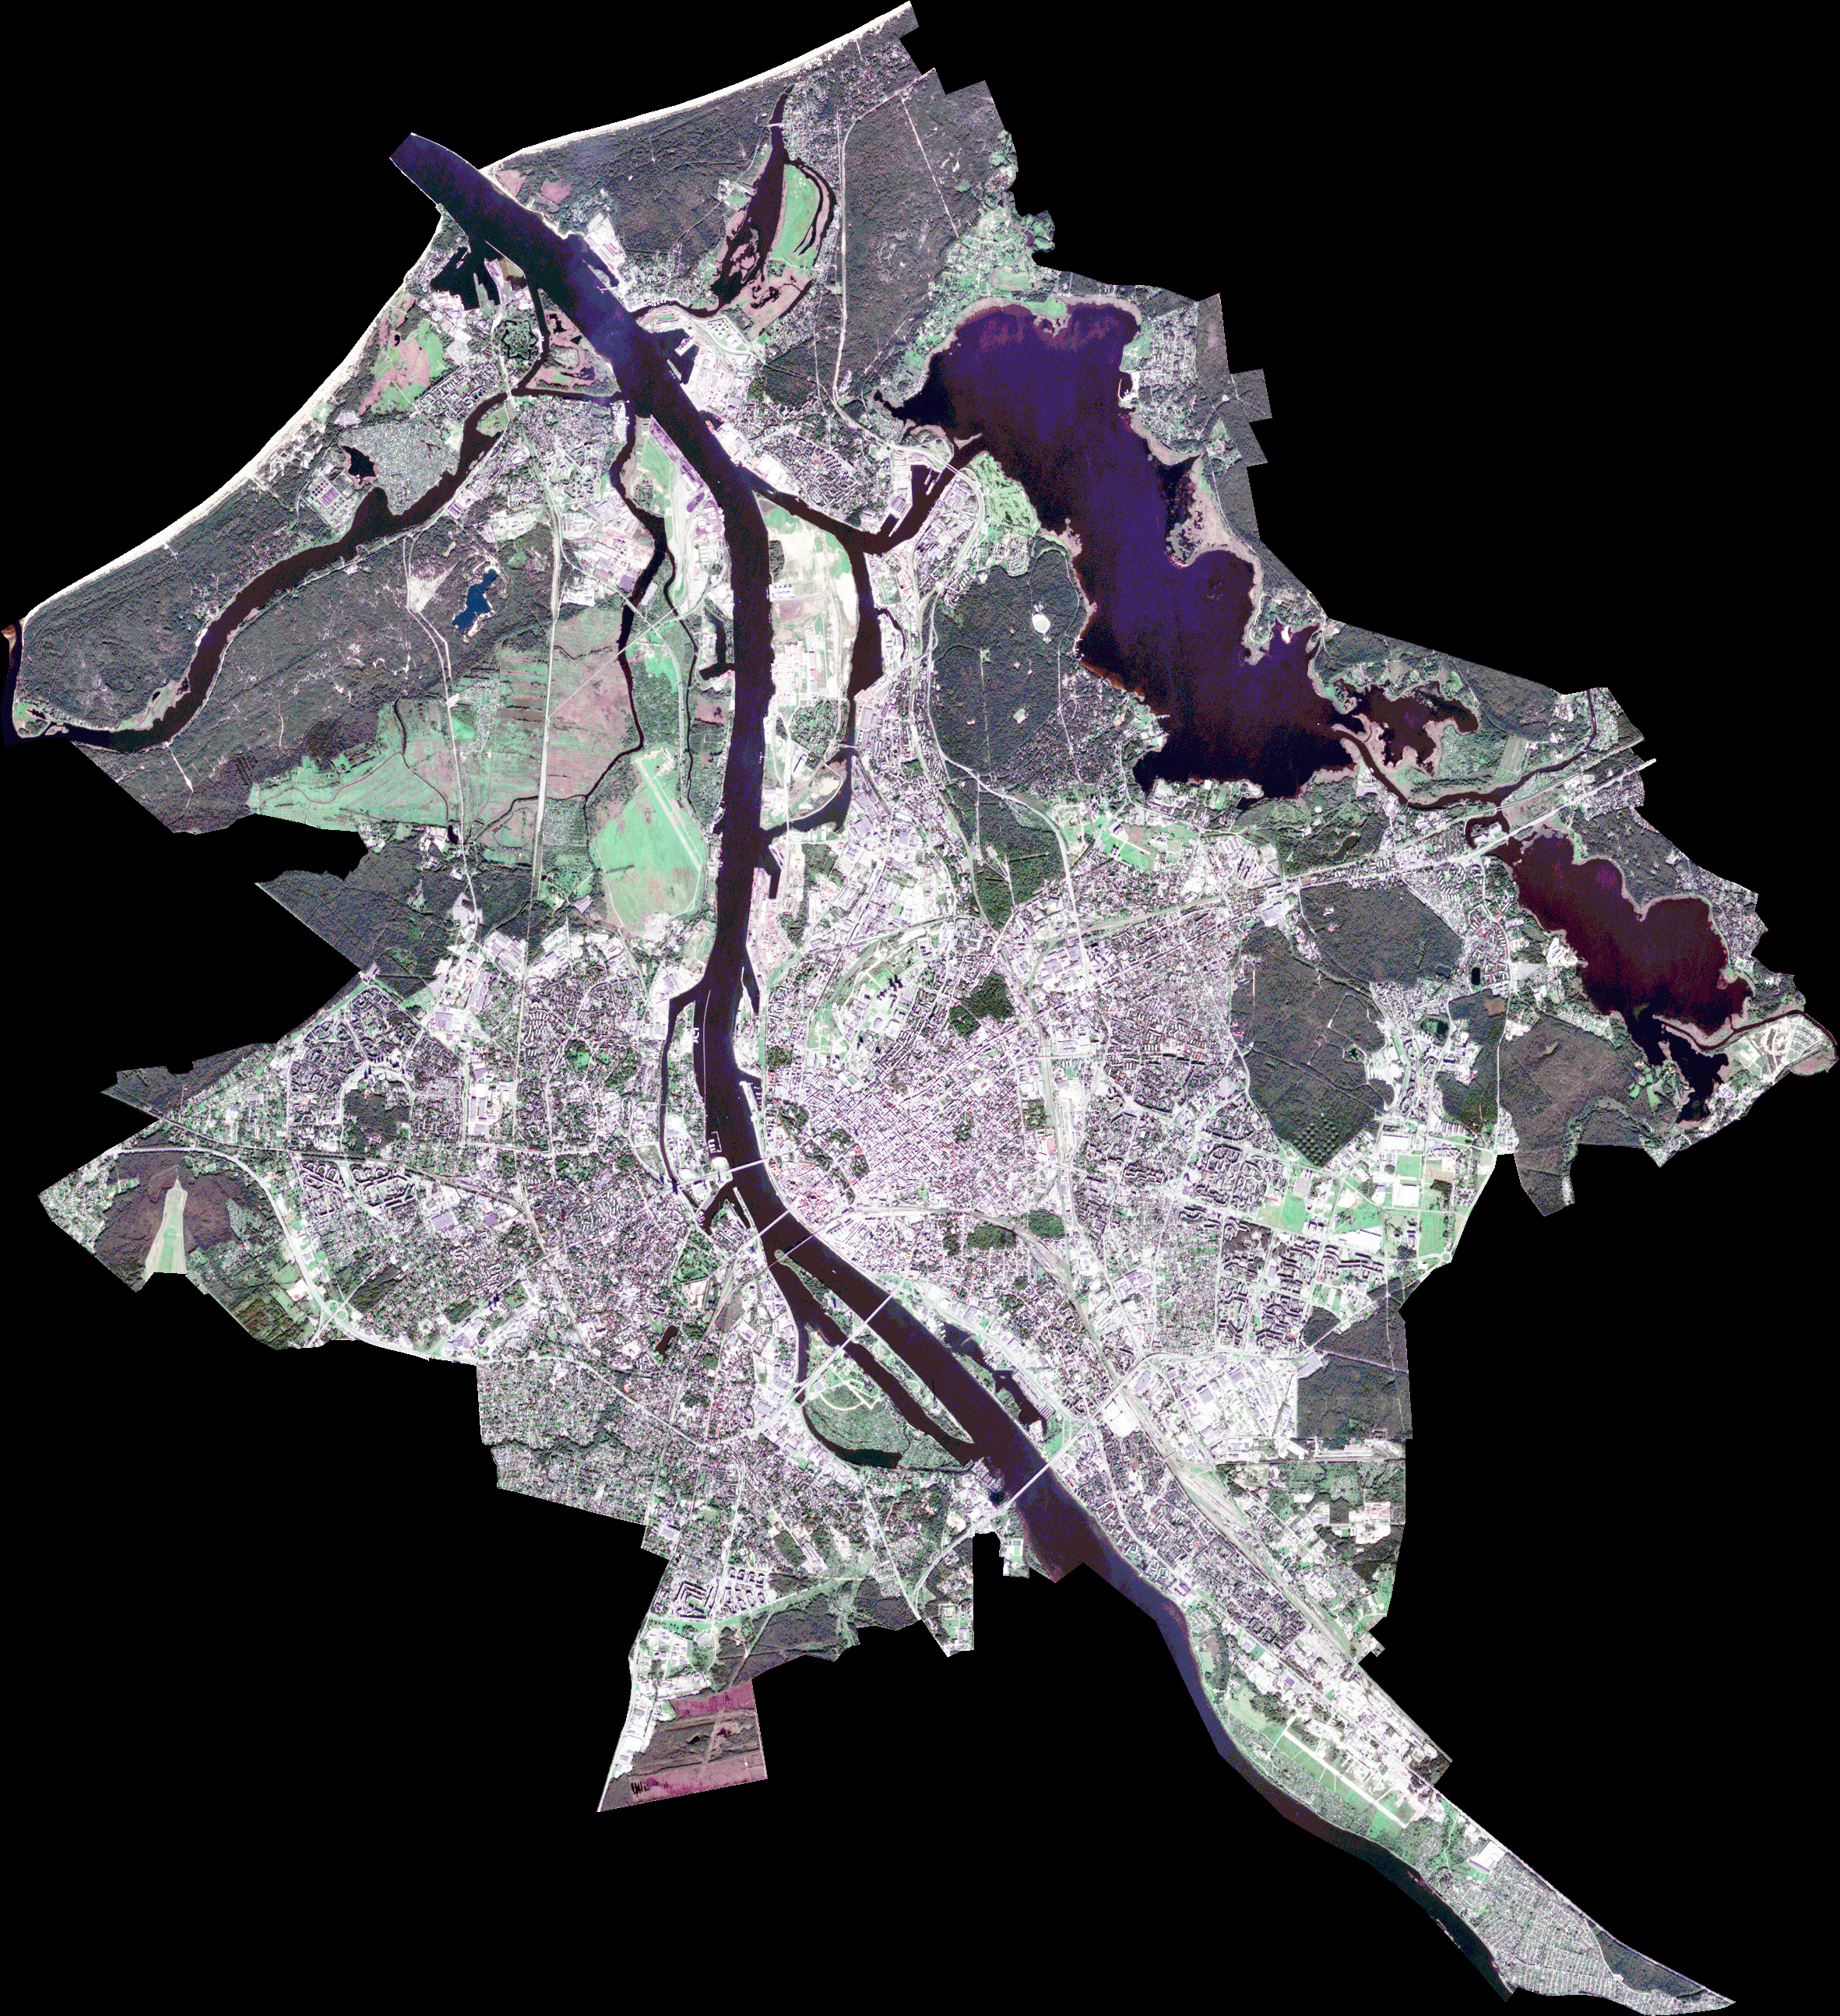

In [ ]:
# Open the file
raster = rasterio.open('/content/stacked_SR.tif')

# Read bands
nir = raster.read(3)
red = raster.read(2)
green = raster.read(1)

# Stack bands
nrg = np.dstack((nir, red, green))

# Normalize the RGB data
nrg_normalized = nrg / nrg.max()

# Create a folium map
m = folium.Map(location=[56.950217, 24.095764], zoom_start=11)


# Normalize the RGB data
nrg_normalized = (nrg / nrg.max() * 255).astype(np.uint8)

# Apply histogram equalization independently to each channel
nrg_equalized = np.zeros_like(nrg_normalized)
for i in range(3):
    nrg_equalized[:, :, i] = cv2.equalizeHist(nrg_normalized[:, :, i])

# Save the image with transparency
cv2.imwrite('/content/temp_image.png', cv2.cvtColor(nrg_equalized, cv2.COLOR_RGB2BGR))

temp_jpeg_path = '/content/temp_image.png'

# Add the JPEG image as an overlay
folium.raster_layers.ImageOverlay(
    image=temp_jpeg_path,
    bounds= degree_bbox,
    opacity=1,
    name='Sentinel-2 RGB',  # Name for the layer
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)
m

# Mathematical procedures with spectral images ---> Calculate NDVI

The Normalized Difference Vegetation Index (NDVI) is a widely used vegetation index that quantifies the presence and health of vegetation in remote sensing data, particularly satellite imagery. NDVI is calculated using the near-infrared (NIR) and red (RED) bands of the electromagnetic spectrum.

NDVI is a fundamental tool in understanding the Earth's surface and has become integral in various fields, contributing valuable insights into the dynamics of vegetation and ecosystems.

In [ ]:
#Selecting the channels
b4 = rasterio.open('/content/clipped_B04.tif') # Opening the red channel
b8 = rasterio.open('/content/clipped_B08.tif') # Opening the infra-red channel

red = b4.read(1).astype(float)
nir = b8.read(1).astype(float)

#Check the image stats to see wether we will encounter 0 values for our division || Yes, we will --> our image is partially masked
print("NIR Stats:", np.min(nir), np.max(nir), np.mean(nir))
print("Red Stats:", np.min(red), np.max(red), np.mean(red))

# Add a small constant to the denominator to avoid division by zero
denominator = (nir + red) + 0.0001

# Calculate NDVI, setting NaN for cases where the denominator is zero
ndvi = np.where(denominator == 0, np.nan, (nir - red) / denominator)

# Prepare metadata
meta = b4.meta
meta.update(driver='GTiff')
meta.update(dtype=rasterio.float32, count=1)

# Save NDVI as GeoTIFF
with rasterio.open('NDVI.tif', 'w', **meta) as dst:
    dst.write(ndvi.astype(rasterio.float32), 1)

NIR Stats: 0.0 16576.0 1404.3701963791927
Red Stats: 0.0 17120.0 719.5505703269162


Plotting the resulting NDVI image

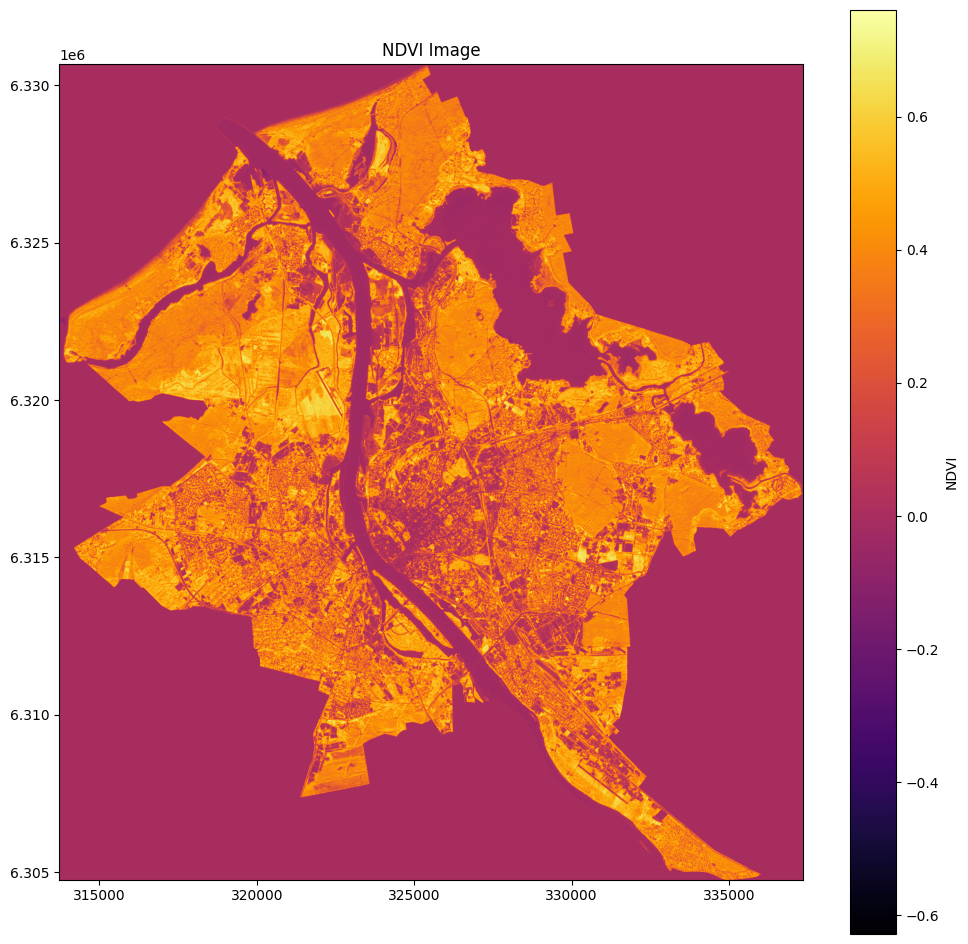

In [ ]:
# Open the NDVI GeoTIFF file
ndvi_file = '/content/NDVI.tif'
with rasterio.open(ndvi_file) as src:
    ndvi = src.read(1)

# Plot the NDVI image and Set the figure size
plt.figure(figsize=(12, 12))
plt.imshow(ndvi, cmap='inferno', extent=[raster.bounds.left, raster.bounds.right, raster.bounds.bottom, raster.bounds.top])
plt.colorbar(label='NDVI')
plt.title('NDVI Image')
plt.show()

**Extracting the values from generated product**

We will use rasterstats python library to obtain the statistics of NDVI image

In [ ]:
# Open the NDVI GeoTIFF file
ndvi_file = 'NDVI.tif'
with rasterio.open(ndvi_file) as ndvi_src:
    # Read the shapefile
    aoi_geom = gpd.read_file('/content/Riga_bounds.shp')
    aoi_geom = aoi_geom.to_crs(ndvi_src.crs)  # Set the CRS of the shapefile to match the NDVI file

    # Use rasterstats to calculate zonal statistics (mean, median, min, max NDVI)
    stats = zonal_stats(aoi_geom.geometry, ndvi_file, stats=["mean", "median", "min", "max"], nodata=np.nan)

    # Create a GeoDataFrame with the zonal statistics
    gdf_stats = gpd.GeoDataFrame(stats, geometry=aoi_geom.geometry)

    # Extract the statistics values
    mean_ndvi = stats[0]['mean']
    median_ndvi = stats[0]['median']
    min_ndvi = stats[0]['min']
    max_ndvi = stats[0]['max']

# Print the statistics values
print(f"Mean NDVI Value: {mean_ndvi}")
print(f"Median NDVI Value: {median_ndvi}")
print(f"Min NDVI Value: {min_ndvi}")
print(f"Max NDVI Value: {max_ndvi}")

Mean NDVI Value: 0.28937755925435255
Median NDVI Value: 0.3471842408180237
Min NDVI Value: -0.6282308101654053
Max NDVI Value: 0.7605421543121338


The results were also stored in geopandas data frame

In [ ]:
gdf_stats

,min,max,mean,median,geometry
0,-0.628231,0.760542,0.289378,0.347184,"POLYGON ((313739.085 6322547.796, 313822.862 6..."
